# PsychrometricPlot

`PsychrometricPlot` places a thermal comfort model on a psychrometric chart: dry-bulb temperature on the x-axis and humidity ratio on the y-axis. Constant relative-humidity curves are drawn automatically. The class converts each grid point's humidity ratio to relative humidity before calling the model, so you pass the model function directly with no extra setup.

Note that `tdb` and `hr` are the fixed axis names — this chart type enforces them.

In [2]:
import matplotlib.pyplot as plt

from pythermalcomfort.models import pmv_ppd_ashrae, pmv_ppd_iso
from pythermalcomfort.plots.matplotlib import PsychrometricPlot

## 1. PMV ISO on a Psychrometric Chart

This is the standard psychrometric view for ISO 7730 comfort assessment. The y-axis runs in humidity ratio (kg water per kg dry air). The grey curves in the background are constant relative humidity lines at 10 % intervals — they appear automatically.

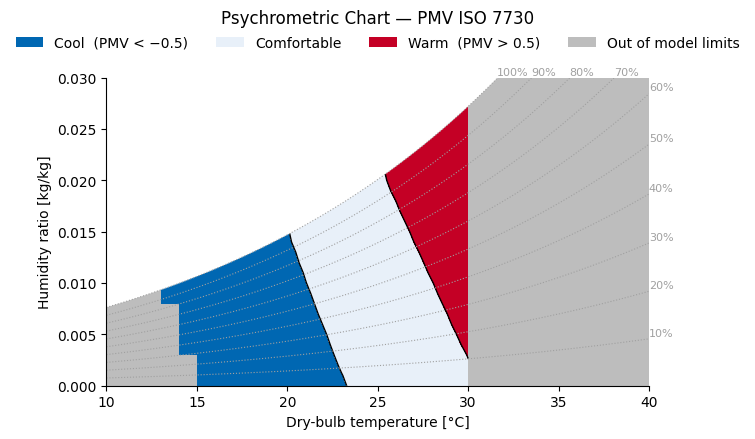

In [3]:
psy_iso = (
    PsychrometricPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=1.0)
    .set_y_axis("hr", 0.0, 0.030, resolution=0.001)
    .set_params(vr=0.10, met=1.2, clo=0.5, tr=25.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cool  (PMV < −0.5)", "Comfortable", "Warm  (PMV > 0.5)"],
        colors=["#0067B2", "#E8F0F9", "#C40025"],
    )
    .plot(title="Psychrometric Chart — PMV ISO 7730")
)
psy_iso.ax.set_xlabel("Dry-bulb temperature [°C]")
psy_iso.ax.set_ylabel("Humidity ratio [kg/kg]")
plt.show()

## 2. PMV ASHRAE 55

The ASHRAE 55 PMV model uses the same psychrometric axes but applies slightly different applicability limits. Running both models side by side makes the differences in their valid regions visible.

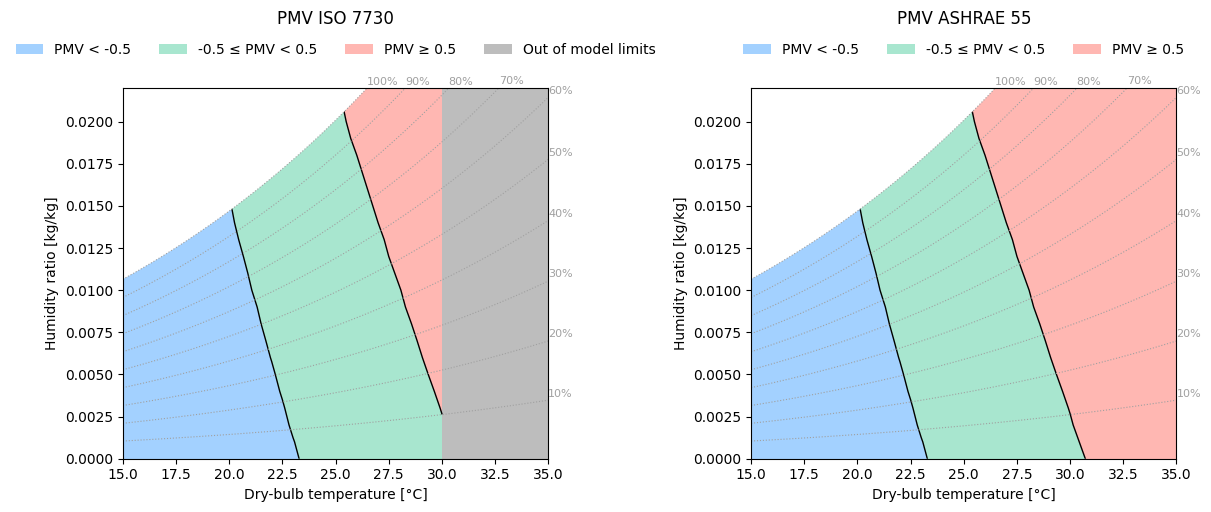

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

(
    PsychrometricPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 15.0, 35.0, resolution=0.5)
    .set_y_axis("hr", 0.0, 0.022, resolution=0.001)
    .set_params(vr=0.10, met=1.2, clo=0.5, tr=25.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax0, title="PMV ISO 7730")
).ax.set(xlabel="Dry-bulb temperature [°C]", ylabel="Humidity ratio [kg/kg]")

(
    PsychrometricPlot(pmv_ppd_ashrae)
    .set_x_axis("tdb", 15.0, 35.0, resolution=0.5)
    .set_y_axis("hr", 0.0, 0.022, resolution=0.001)
    .set_params(vr=0.10, met=1.2, clo=0.5, tr=25.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(ax=ax1, title="PMV ASHRAE 55")
).ax.set(xlabel="Dry-bulb temperature [°C]", ylabel="Humidity ratio [kg/kg]")

plt.show()

## 3. Custom Labels and Colors

Labels and colors work the same way as in `ThresholdPlot`. Pass them to `set_regions` and they appear in the legend.

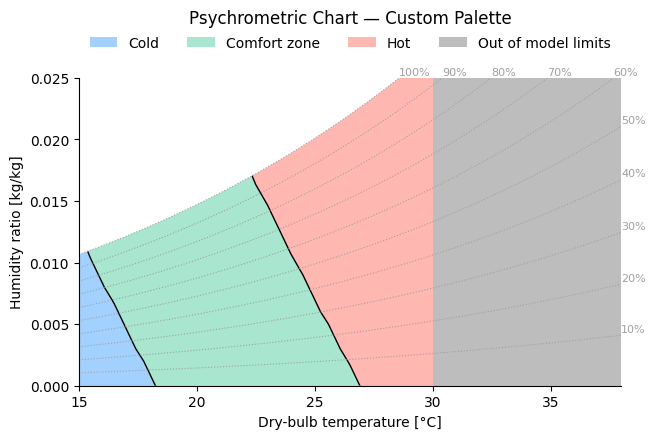

In [8]:
psy_custom = (
    PsychrometricPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 15.0, 38.0, resolution=0.5)
    .set_y_axis("hr", 0.0, 0.025, resolution=0.001)
    .set_params(vr=0.15, met=1.4, clo=0.7, tr=25.0)
    .set_regions(
        output="pmv",
        thresholds=[-0.5, 0.5],
        labels=["Cold", "Comfort zone", "Hot"],
        colors=["#A3D1FF", "#A8E6CF", "#FFB7B2"],
    )
    .plot(title="Psychrometric Chart — Custom Palette")
)
psy_custom.ax.set_xlabel("Dry-bulb temperature [°C]")
psy_custom.ax.set_ylabel("Humidity ratio [kg/kg]")
plt.show()

## 4. Styling and Legend Control

Use `fill_kws`, `line_kws`, and `legend_kws` to adjust the appearance. `legend=False` removes the colour key when the chart is being combined with another plot that already carries the legend.

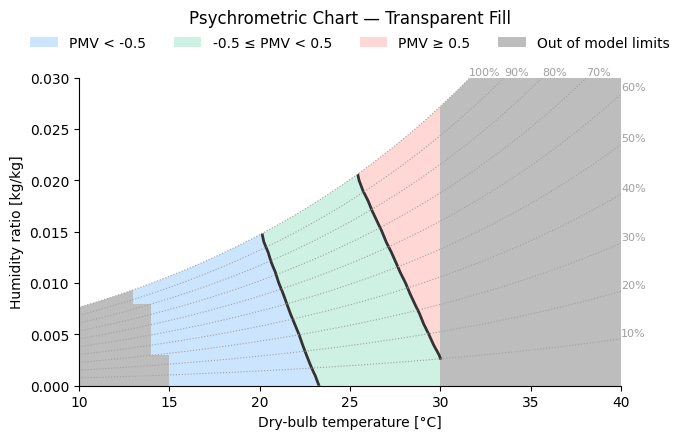

In [9]:
psy_styled = (
    PsychrometricPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=1.0)
    .set_y_axis("hr", 0.0, 0.030, resolution=0.001)
    .set_params(vr=0.10, met=1.2, clo=0.5, tr=25.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot(
        title="Psychrometric Chart — Transparent Fill",
        fill_kws={"alpha": 0.55},
        line_kws={"linewidth": 2.0, "color": "#333333"},
    )
)
psy_styled.ax.set_xlabel("Dry-bulb temperature [°C]")
psy_styled.ax.set_ylabel("Humidity ratio [kg/kg]")
plt.show()

## 5. Using result.fig and result.ax

`result.fig` and `result.ax` follow the same conventions as in `ThresholdPlot`. Use `result.fig.suptitle` for figure-level text or `result.fig.savefig` to write the chart to disk.

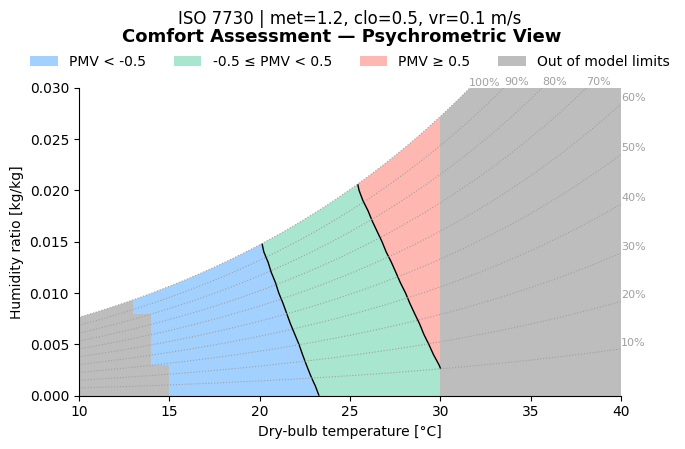

In [10]:
r = (
    PsychrometricPlot(pmv_ppd_iso)
    .set_x_axis("tdb", 10.0, 40.0, resolution=1.0)
    .set_y_axis("hr", 0.0, 0.030, resolution=0.001)
    .set_params(vr=0.10, met=1.2, clo=0.5, tr=25.0)
    .set_regions(output="pmv", thresholds=[-0.5, 0.5])
    .plot()
)

r.fig.suptitle(
    "Comfort Assessment — Psychrometric View", y=1.03, fontsize=13, fontweight="bold"
)
r.ax.set_title("ISO 7730 | met=1.2, clo=0.5, vr=0.1 m/s", y=1.18)
r.ax.set_xlabel("Dry-bulb temperature [°C]")
r.ax.set_ylabel("Humidity ratio [kg/kg]")

# r.fig.savefig("psychrometric_pmv.png", dpi=150, bbox_inches="tight")
plt.show()